# 🌿 Cost–Benefit Analysis of Increasing Canopy Cover

This notebook aims to assess the **cost–benefit relationship of agroforestry systems**, focusing on their impact on the **value chain of tropical perennial crops** — specifically through the **ecosystem service of microclimate regulation**.

Agroforestry provides multiple ecosystem services, including: moisture retention, protection from intense sunlight, and humidity regulation. In this analysis, we concentrate on the **cooling benefit** of shade trees. We model this cooling effect as a **reduction in maximum daily temperature**, which is assumed to be a function of **canopy cover** — used here as a proxy for shade level.

The goal is to quantify how changes in canopy cover affect crop yields through **climate hazard modification**, and to assess whether the **costs of implementing shading measures** are justified by their **benefits in yield protection**.

- **Hazards**: Mean yearly **Vapour Pressure Deficit (VPD)**  Mean yearly **maximum temperature (TASMAX)**

- **Exposure**: Average crop yield (or production) per location

- **Impact Function**: Estimated **relative yield reduction** as a function of the above hazards

From a technical viewpoint, the idea is that the condition of the ecosystem service (indicated by the biodiversity indicator) influences the hazard, exposure, and impact function.

- **Biodiversity Link**: The **ecosystem condition**, reflected by **canopy cover**, modifies the hazard (e.g., via cooling) and potentially the impact.

We also incorporate uncertainty parameters such as adaptation cooling effect, cost assumptions, and canopy cover scenarios to produce a **distribution of risk and cost–benefit outcomes**.

The valubel outcome of such a 

The notebook contains configurable parameters such as country, crop type, and biophysical assumptions (e.g. cooling curve). Although this notebook focuses on microclimate regulation, the same structure can be adapted to other ecosystem services. For instance, canopy cover could influence:
- Humidity (linking to VPD)
- Soil retention (linking to erosion/flooding)
- Pollination or pest control (via biodiversity)

This notebook is developed using the old cost-benefot module to get an idea how canopy cover could be incoorporate to asses cost-benfit in the aspect of the value-chain. FOr the future develop of the cost-benfit or other ad-hoc development one could consider . 

This note complements the notebook looking at the rsik to the biodiversity and ecosystem sercie itseld. A third intention is too couple the too to see how the harm to ecossytem service results in a risk on the value-cahin.


Uncertainty parameters 
- 
- Possible in next section e.g., canopy cover 

*Data sources (make table and give options, e.g., calibrated impact function)*

*References (to be added later)*


## Step 1 - Initate

Global parameters

In [1]:
from pathlib import Path
import os

# Define output and input directories (make clean directories for UNU)
INPUT_DIR = Path(os.path.join(os.getcwd(), '..', 'data')).resolve()
OUTPUT_DIR = Path(os.path.join(os.getcwd(), '..', 'output')).resolve()

# Decide country code based on the bounding box
country = 'MEX' # 'MEX' for Mexico, 'GTM' for Guatemala, and 'DOM' for Dominican Republic

# Decide the crop
crop = 'coffee' # 'coffee' for coffee, 'cacao' for cacao, and 'banana' for banana

# Define the hazard type
hazard_type = 'VPD'

## Step 2 - Exposure

Here we derive the crop production (t/y) per grid cell from the 2020 maspam data 

- Data from: [https://mapspam.info](https://mapspam.info) [Read me](https://www.dropbox.com/scl/fi/z468wh0d8abfohol991r5/Readme.txt?rlkey=el1w3zeykz909aadrx2xuck36&e=1&dl=0)

We remove grip points that have no production.

Note that we dont have actual production sites so we use grid cells.


In [2]:
from utils_cb import get_crop_prod_exposure, COUNTRY_BOUNDS, FILES_CROP_PROD, FILES_CROP_HARVEST

# Get the exposure object for the given crop and bounding box
exp = get_crop_prod_exposure(file = INPUT_DIR / FILES_CROP_PROD[crop], # file path to the crop production data
                                             bbox = COUNTRY_BOUNDS[country], # bounding box for the country
                                            hazard_type = hazard_type, # hazard type (e.g., 'VPD', 'Tmax', etc.)
                                            harvest_area_file= INPUT_DIR / FILES_CROP_HARVEST[crop] # file path to the harvest area data
                                            ) 

Look at the exposure

+----+---------+------------+---------------------+------------------------------------------------+
|    |   value |   impf_VPD |   harvest_area (ha) | geometry                                       |
|----+---------+------------+---------------------+------------------------------------------------|
|  0 |     0.1 |          1 |                 1   | POINT (-100.9583333333513 23.87500000001502)   |
|  1 |     0.1 |          1 |                 1   | POINT (-100.87500000001799 23.87500000001502)  |
|  2 |     0.1 |          1 |                 1   | POINT (-100.79166666668468 23.87500000001502)  |
|  3 |     0.6 |          1 |                 5.9 | POINT (-100.9583333333513 23.791666666681706)  |
|  4 |     0.1 |          1 |                 1   | POINT (-100.70833333335136 23.791666666681706) |
+----+---------+------------+---------------------+------------------------------------------------+


<GeoAxes: >

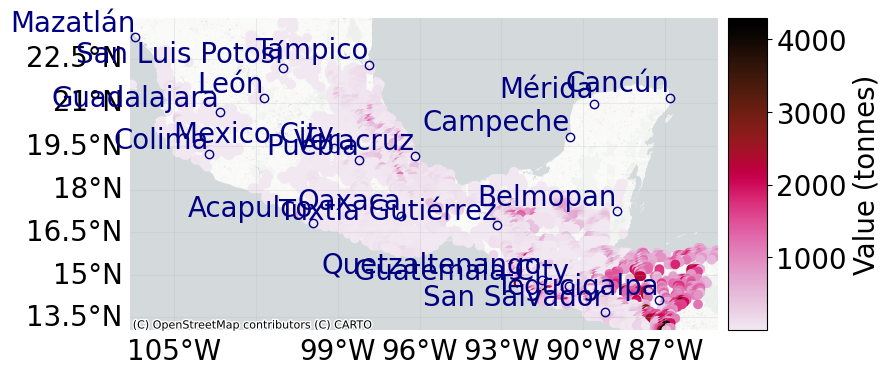

In [3]:
from tabulate import tabulate

# Print and plot the exposure object
print(tabulate(exp.gdf.head(), headers='keys', tablefmt='psql'))

# Plot the exposure object
exp.plot_basemap()

Add the canopy cover

- https://www.globalforestwatch.org/
- https://earthenginepartners.appspot.com/science-2013-global-forest/download_v1.7.html

For now just remove crop production grid points that give no canopy cover

IMPORTANT: Get better spatial resolution. Use Zelies data from canopy_cover to downscale where the actual coffe plantation is and where the acroforesty is. The maps resolution of 10 km x 10 km is to crude for canopy cover approximation. However start with this approach to see how the cost-benefit calcualtiona and unsequa could work.

Make a canopy cover estimate for each site location if not given in the exposure file

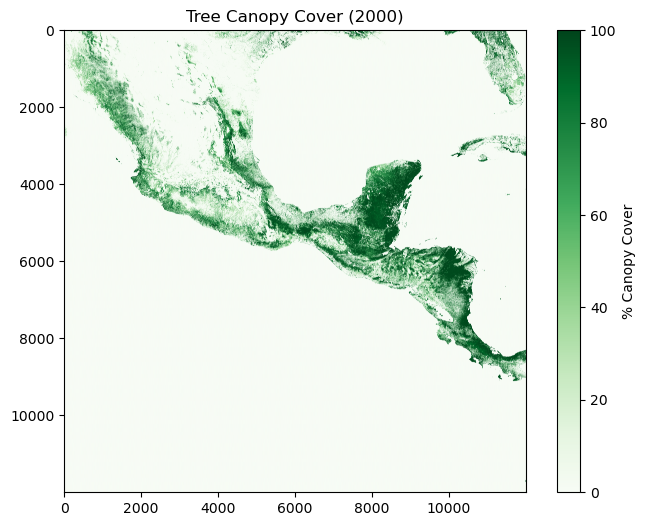

In [4]:
from utils_cb import merge_rasters, downsample_raster, add_canopy_cover_to_exposure
import matplotlib.pyplot as plt

# --- CONFIG ---
canopy_tif_path = INPUT_DIR / "merged_treecover2000.tif" # Path to the canopy raster file


# Load the merged raster file
if not canopy_tif_path.exists():
    print("Merged file not found. Creating...")
    merge_rasters(input_dir = INPUT_DIR / "Hansen_TreeCover", # input directory containing the raster tiles
                 output_path = canopy_tif_path # output path for the merged raster
                    )

# Plot
downsampling_factor = 10  # or None for full resolution for faster plotting
plt.figure(figsize=(8, 6))
plt.imshow(downsample_raster(canopy_tif_path, downsampling_factor), 
           cmap='Greens')
plt.colorbar(label='% Canopy Cover')
title = f"Tree Canopy Cover (2000)"
plt.title(title)
plt.show()

We add the canopy cover

In [6]:
# Add canopy cover to the exposure object
buffer_m = 500  # Buffer in meters for the exposure points
exp_with_canopy = add_canopy_cover_to_exposure(exp, canopy_tif_path, buffer_m)
print(tabulate(exp_with_canopy.gdf[["value", "canopy_cover", "harvest_area (ha)"]].head(), headers='keys', tablefmt='psql'))

+----+---------+----------------+---------------------+
|    |   value |   canopy_cover |   harvest_area (ha) |
|----+---------+----------------+---------------------|
|  4 |     0.1 |        1       |                 1   |
|  7 |     0.6 |       12.1688  |                 7   |
|  8 |     0.7 |       12.6     |                 7.2 |
| 17 |     0.3 |        4.81111 |                 4.9 |
| 28 |     0.6 |       18.0494  |                 5.8 |
+----+---------+----------------+---------------------+


We define `exp_base` as the exposure object used in the subsequent steps. This will be the base input for all subsequent uncertainty modeling steps.

In [7]:
import copy

exp_base = copy.deepcopy(exp_with_canopy)  # Create a base copy of the exposure object with canopy cover

## Step 3 - Get the Hazard

The hazard intensity for VPD depends on the canopy cover 

In [8]:
from utils_cb import load_isimip_multi_and_subset

# Load ISIMIP data for tas and hurs
tas_files = sorted(INPUT_DIR.glob("Isimip/20crv3-era5_obsclim_tas_global_daily_*.nc"))
hurs_files = sorted(INPUT_DIR.glob("Isimip/20crv3-era5_obsclim_hurs_global_daily_*.nc"))

# Define bounding box for the region of interest
tas_gs, hurs_gs = load_isimip_multi_and_subset(tas_files,
                                               hurs_files,
                                                bbox=COUNTRY_BOUNDS[country])



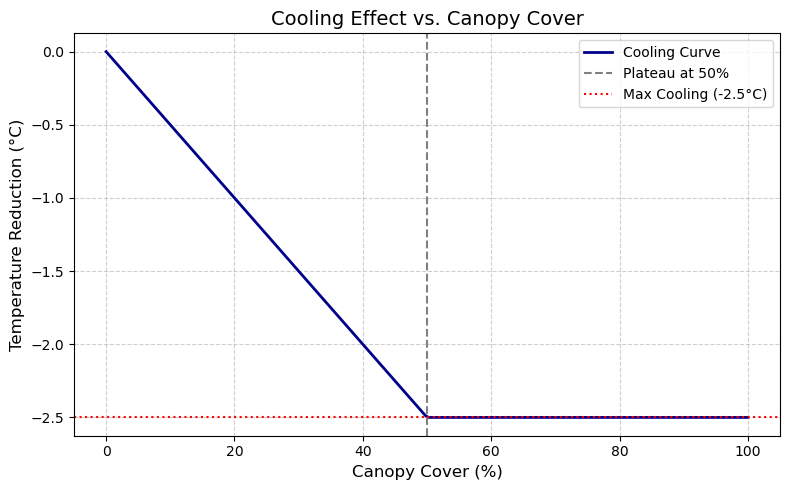

In [9]:
from utils_cb import canopy_cooling
import numpy as np

# Plot the cooling function
canopy = np.linspace(0, 100, 200)
max_cooling = 2.5  # Updated max cooling
plateau_at = 50    # Updated plateau point
cooling = canopy_cooling(canopy, max_cooling=max_cooling, plateau_at=plateau_at)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, cooling, label='Cooling Curve', color='darkblue', linewidth=2)
plt.axvline(plateau_at, color='gray', linestyle='--', label=f'Plateau at {plateau_at}%')
plt.axhline(-max_cooling, color='red', linestyle=':', label=f'Max Cooling (-{max_cooling}°C)')

# Styling
plt.title('Cooling Effect vs. Canopy Cover', fontsize=14)
plt.xlabel('Canopy Cover (%)', fontsize=12)
plt.ylabel('Temperature Reduction (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


In [10]:
from utils_cb import compute_vpd_hazard

# Make a dictionary to store the hazard object for the current scenario
haz_dict = {}

# Compute the hazard using the exposure object and the ISIMIP data
if hazard_type == 'VPD':
    # Compute VPD hazard with canopy cooling
    haz_dict['current'] = compute_vpd_hazard(exp_base, tas_gs, hurs_gs,
                                    canopy_scenario= "current", # Canopy scenario to use
                                    cooling_fn=canopy_cooling
                                    )

# plot the VPD hazard object
# haz.plot_intensity(0)

In [25]:
haz_base = copy.deepcopy(haz_dict['current'])  # Create a base copy of the hazard object

## Step 4 - Get the Vulnerability 

##

<Axes: title={'center': 'VPD 1: VPD Empirical Yield Loss'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

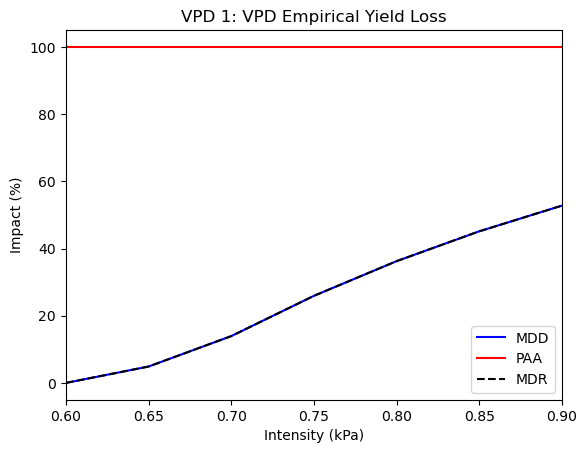

In [11]:
from utils_cb import impact_func_from_kath

impf_vpd = impact_func_from_kath(
    file_path="vpd_effect_approximation.csv",
    intensity_col="Mean_VPD_kPa",
    yield_col="Effect_Central",
    only_yield_losses=True,
    haz_type="VPD",
    unit="kPa",
    name="VPD Empirical Yield Loss"
)

impf_vpd.plot()

## Step 5 - Let define the adaption measures

Increas canopy to at least 50% the aditional cost ... 

In [12]:
# Define the minimum canopy cover
min_canopy_cover = 50  # Minimum canopy cover percentage

# Name the measure 
measure_name = f"Canopy Cover {min_canopy_cover}%"

# Cost parameters
canopy_cost_params = {
    "setup_cost_per_ha": 300,  # Setup cost per hectare
    "annual_maint_cost_per_ha": 30,  # Annual maintenance cost per hectare
    "duration_years": 10,  # Duration of the investment in years
}

Calculate the cost for it

In [13]:
from utils_cb import compute_additional_canopy_cost

# Compute the additional canopy cost to reach at least 50% canopy cover
total_cost, site_costs, planted_ha_total = compute_additional_canopy_cost(
    exp_base,
    min_canopy_percent=min_canopy_cover,
    **canopy_cost_params
)

print(f"🌳 Total cost to reach at least 50% canopy: ${total_cost:,.0f}")
print(f"🌱 Total canopy area to plant: {planted_ha_total:,.1f} hectares")

current_canopy_ha = (exp_base.gdf["canopy_cover"] / 100) * exp_base.gdf["harvest_area (ha)"]
total_current_canopy_ha = current_canopy_ha.sum()

print(f"🌳 Current total canopy cover: {total_current_canopy_ha:,.1f} hectares")
# Get the percentage of new canopy needed
planted_ha_total = (planted_ha_total / total_current_canopy_ha) * 100 if total_current_canopy_ha > 0 else 0
print(f"🌱 Percentage of new canopy needed: {planted_ha_total:.1f}% of current canopy area")


# Cost parameters
canopy_cost_params = {
    "setup_cost_per_ha": 300,  # Setup cost per hectare
    "annual_maint_cost_per_ha": 30,  # Annual maintenance cost per hectare
    "duration_years": 10,  # Duration of the investment in years
    "default_hektar_per_site": 500  # Default hectares per site for cost calculation
}

🌳 Total cost to reach at least 50% canopy: $59,420,337
🌱 Total canopy area to plant: 99,033.9 hectares
🌳 Current total canopy cover: 783,771.3 hectares
🌱 Percentage of new canopy needed: 12.6% of current canopy area


In [14]:
from utils_cb import compute_vpd_hazard

# Compute the hazard using the exposure object and the ISIMIP data
if hazard_type == 'VPD':
    # Compute VPD hazard with canopy cooling
    haz_dict[measure_name] = compute_vpd_hazard(exp_base, tas_gs, hurs_gs,
                                    canopy_scenario= min_canopy_cover, # Canopy scenario to use
                                    cooling_fn=canopy_cooling
                                    )

# plot the VPD hazard object
# haz.plot_intensity(0)

## Step 6 - Risk Analysis 

Possible uncertainty variables:
- Crop Production (Exposure)
- Impact function (Use range from paper)

- Canopy Cover (Exposure) -> Modifies hazard
- Cooling benefit (Measure) -> Modifies hazard

<Axes: title={'center': 'VPD 1: VPD Random Impact (seed=61)'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

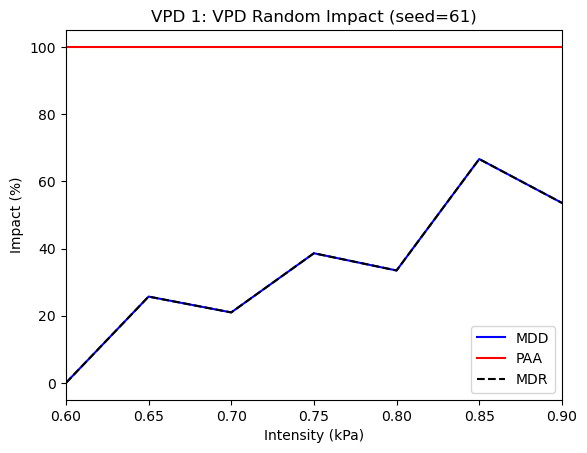

In [15]:
from utils_cb import generate_random_impact_func_from_ci
import scipy as sp

impf_random = generate_random_impact_func_from_ci(
    file_path="vpd_effect_approximation.csv",
    seed = sp.stats.randint(low=1, high=1000).rvs(size=1)[0],  # Random number of sites between 1 and 1000
    name="VPD Random Impact"
)
impf_random.plot()


In [16]:
import copy
import scipy as sp
from functools import partial

from climada.engine.unsequa import InputVar
from climada.entity import ImpactFuncSet

## Define the uncertainty variables for the exposure, impact function set, and hazard
# Exposure
exp_distr = {
    "e_value": sp.stats.uniform(0.5, 1.0), # Uniform distribution between 0.5 and 1.5 multiply with the crop productivity value
}

# Impact function set
impf_distr = {
    "i_seed": sp.stats.randint(low=1, high=1000), # Uniform distribution between 1 and 100 determines the random seed for the impact function
}



In [34]:
## Define the uncertainty functions for the exposure, impact function set and hazard

# Define the base exposure
def exp_func(e_value, exp_base=exp_base):
    # Copy the base exposure
    exp = copy.deepcopy(exp_base)
    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value
    return exp

# Make a scaled version of the exposure function to get a normalized exposure
def exp_scaled_func(*args, **kwargs):
    exp = exp_func(*args, **kwargs)
    exp.gdf["value"] = exp.gdf["value"] / exp.gdf["value"].sum()
    return exp

# Impact function set
# Define the base impact function set
impf_func = lambda i_seed: ImpactFuncSet([
    generate_random_impact_func_from_ci(
        seed=int(i_seed), # Use the seed from the uncertainty variable
        file_path='vpd_effect_approximation.csv',
        name='Random VPD IF'
    )
])

In [18]:
# Uncertainty variable dicts
exp_ivs = {
    "unscaled": InputVar(exp_func, exp_distr),
    "scaled": InputVar(exp_scaled_func, exp_distr)
}

impf_iv = InputVar(impf_func, impf_distr)

# Outputs split by exposure type and hazard key
output_imp = {
    "unscaled": {},
    "scaled": {}
}


In [19]:
from climada.engine.unsequa import CalcImpact

# Remove the sclaed and unscaled and include in the plot function instead
for key, haz in haz_dict.items():
    for mode in ["unscaled", "scaled"]:
        exp_iv = exp_ivs[mode]
        calc_imp = CalcImpact(exp_iv, impf_iv, haz)
        samples = calc_imp.make_sample(N=2**7, sampling_kwargs={"skip_values": 2**8})
        result = calc_imp.uncertainty(samples, rp=list(range(1, 40)))
        output_imp[mode][key] = result


Plot the distribution

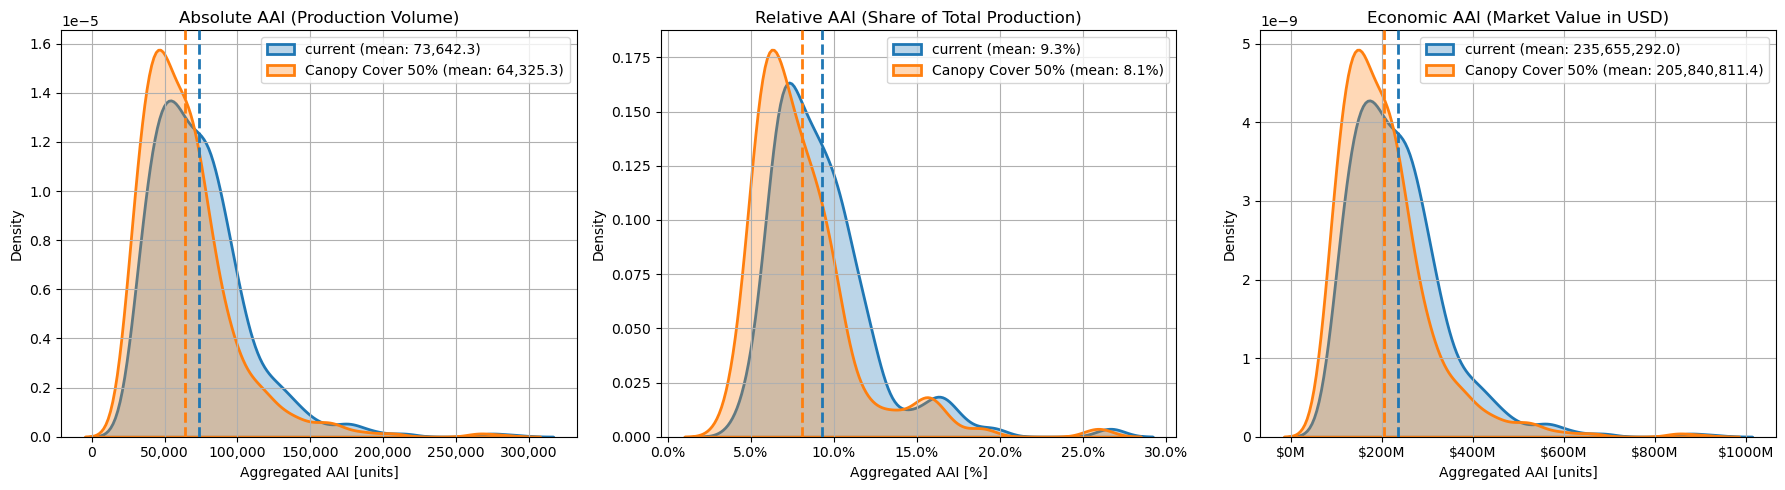

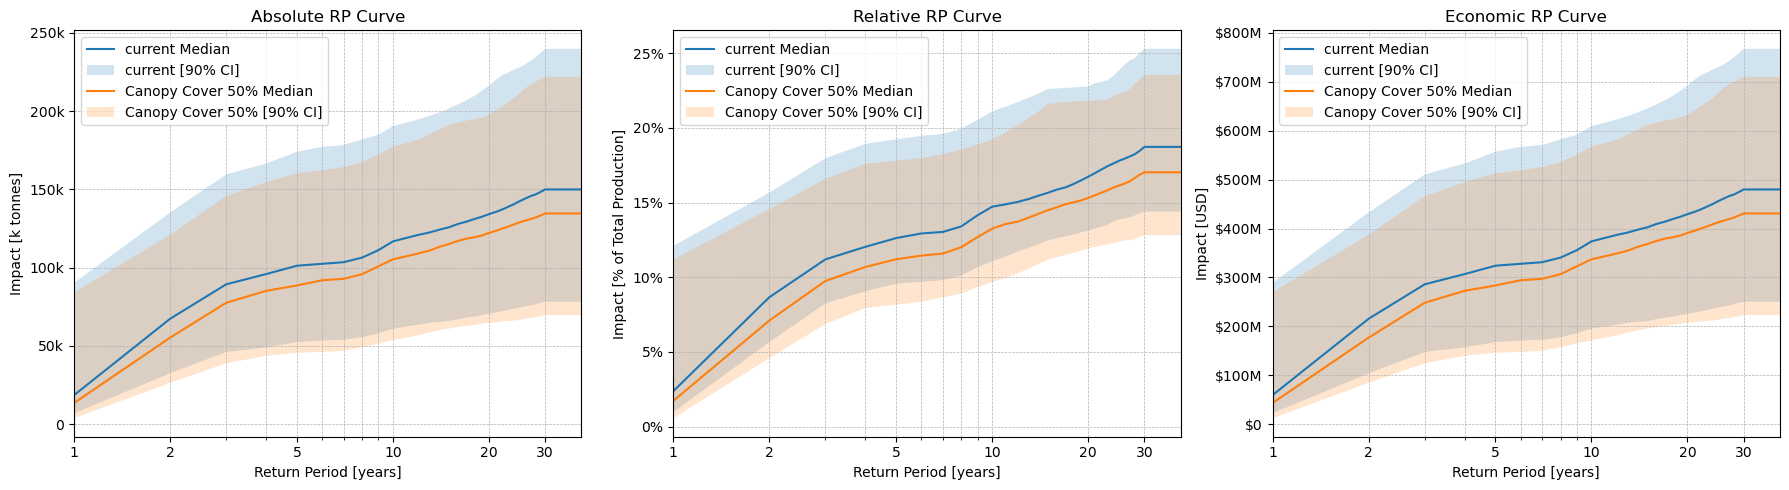

In [20]:
from utils_cb import plot_kde_and_rp_panels

plot_kde_and_rp_panels(output_imp, price_per_ton=3200)


Sensitivty analysis - What is describing the variation

In [21]:
# output_imp = calc_imp.sensitivity(output_imp)
# output_imp.sensitivity_metrics
# # Default for 'sobol' is to plot 'S1' sensitivity index.
# output_imp.plot_sensitivity(figsize=(12, 8));

## Step 6 - Define the measures

Here we define the measures. We only compare too different shade levels

In [41]:
?Measure

Init signature:
Measure(
    name: str = '',
    haz_type: str = '',
    cost: float = 0,
    hazard_set: str = 'nil',
    hazard_freq_cutoff: float = 0,
    exposures_set: str = 'nil',
    imp_fun_map: str = 'nil',
    hazard_inten_imp: Tuple[float, float] = (1, 0),
    mdd_impact: Tuple[float, float] = (1, 0),
    paa_impact: Tuple[float, float] = (1, 0),
    exp_region_id: Optional[list] = None,
    risk_transf_attach: float = 0,
    risk_transf_cover: float = 0,
    risk_transf_cost_factor: float = 1,
    color_rgb: Optional[numpy.ndarray] = None,
)
Docstring:     
Contains the definition of one measure.

Attributes
----------
name : str
    name of the measure
haz_type : str
    related hazard type (peril), e.g. TC
color_rgb : np.array
    integer array of size 3. Color code of this measure in RGB
cost : float
    discounted cost (in same units as assets)
hazard_set : str
    file name of hazard to use (in h5 format)
hazard_freq_cutoff : float
    hazard frequency cutoff
exposures

In [ ]:
from climada.entity.measures import Measure, MeasureSet

# Define the minimum canopy cover
min_canopy = [50, 60]  # Minimum canopy cover percentage

# Define shared canopy cost parameters
canopy_cost_params = {
    "setup_cost_per_ha": 300,
    "annual_maint_cost_per_ha": 30,
    "duration_years": 10
}


Stored hazard 50 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_vpd_50.h5
Stored hazard 60 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_vpd_60.h5


Define the measures

In [ ]:
# Create a meaure set to store the measures
meas_set = MeasureSet()

# For each canopy cover percentage, define the measure by computing the hazard and cost
for canopy in min_canopy:
    # Compute the hazard using the exposure object and the ISIMIP data
    if hazard_type == 'VPD':
        # Compute VPD hazard with canopy cooling
        haz_meas = compute_vpd_hazard(exp_base, tas_gs, hurs_gs,
                                        canopy_scenario= canopy, # Canopy scenario to use
                                        cooling_fn=canopy_cooling
                                        )
        # Save the hazard to the output directory
        haz_file = OUTPUT_DIR / f"haz_vpd_{canopy}.h5"
        haz_meas.write_hdf5(haz_file)
        print(f"Stored hazard {canopy} in {OUTPUT_DIR / f'haz_vpd_{canopy}.h5'}")
    
    # Define the measure
    meas =  Measure(
        name= f"Canopy Cover {min_canopy_cover}%", # Name of the measure
        haz_type = hazard_type,
        # Give the measure a random color
        color_rgb = np.random.rand(3,),
        cost = compute_additional_canopy_cost(exp_base, min_canopy_percent=min_canopy_cover, **canopy_cost_params)[0],
        hazard_set = OUTPUT_DIR / "haz_vpd_shaded.h5")
    
    # Append the measure to the measure set
    meas_set.append(meas)
    meas_set.check()

In [55]:
?meas_set

Type:           MeasureSet
String form:    <climada.entity.measures.measure_set.MeasureSet object at 0x3539d0210>
File:           ~/Documents/Programming/Climate/climada_python/climada/entity/measures/measure_set.py
Docstring:     
Contains measures of type Measure. Loads from
files with format defined in FILE_EXT.

Attributes
----------
_data : dict
    Contains Measure objects. This attribute is not suppossed to be accessed directly.
    Use the available methods instead.
Init docstring:
Initialize a new MeasureSet object with specified data.

Parameters
----------
measure_list : list of Measure objects, optional
    The measures to include in the MeasureSet

Examples
--------
Fill MeasureSet with values and check consistency data:

>>> act_1 = Measure(
...     name='Seawall',
...     color_rgb=np.array([0.1529, 0.2510, 0.5451]),
...     hazard_intensity=(1, 0),
...     mdd_impact=(1, 0),
...     paa_impact=(1, 0),
... )
>>> meas = MeasureSet([act_1])
>>> meas.check()

Read measures 

## Step 7 - Cost Benefit

- Cost (Measure)
- Value of future crops (Entity)

Here it is important to asses the value of canopy 

In [ ]:
# A parameter here is what is the baseline is it the current level of canopy cover

Make the basic entity objects

In [ ]:
n_years = 20

<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

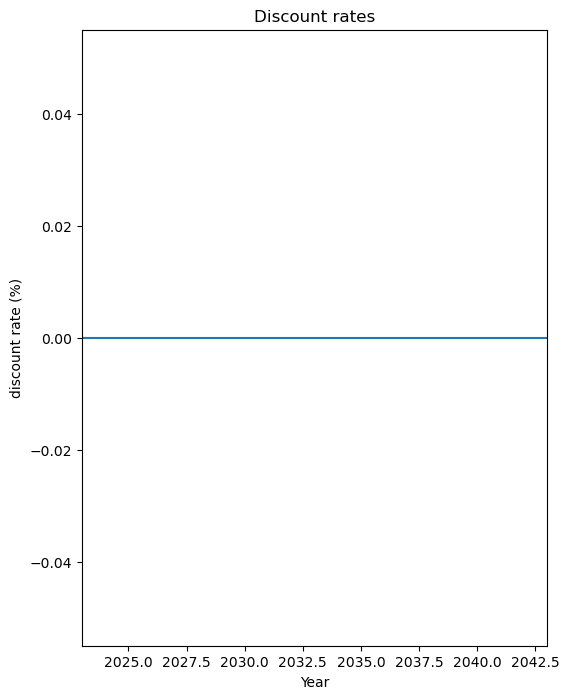

In [37]:
from climada.entity import DiscRates


CURRENT_YEAR = 2023  # Current year for the discount rate calculation
n_years = 20  # Number of years for the discount rate calculation


# Create a range of years for the discount rate
FUTURE_YEAR = CURRENT_YEAR + n_years  # Future year for the discount rate calculation
year_range = np.arange(CURRENT_YEAR, FUTURE_YEAR + 1) # Create an array of years from the current year to the future year
annual_discount = np.zeros(n_years +1)  # Create an array of zeros for the discount rates
disc_base = DiscRates(year_range, annual_discount)

# Plot the discount rates
disc_base.plot()

Define the uncertainty variables

In [38]:
ent_today_distr = {"e_value": sp.stats.uniform(0.7, 1),
                   "m_cost": sp.stats.uniform(0.5, 1)
                   }

Define ...

In [ ]:
impf_vpd

In [46]:
import copy
from climada.util.constants import ENT_DEMO_TODAY, ENT_DEMO_FUTURE, HAZ_DEMO_H5
from climada.entity import Entity
from climada.hazard import Hazard


# Entity today has an uncertainty in the total asset value
def ent_today_func(e_value, m_cost, # The uncertainty parameters
                   exp_base=exp_base, impf_func_base=ImpactFuncSet([impf_vpd]), measure_set_base=meas_set, disc_base=disc_base # The base objects to copy and modify
                   ):
    # Copy the base objects
    exp = copy.deepcopy(exp_base)
    exp.ref_year = CURRENT_YEAR # Set the reference year for the exposure
    impf_func_set = copy.deepcopy(impf_func_base)
    meas_set = copy.deepcopy(measure_set_base)
    disc_rate = copy.deepcopy(disc_base)


    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value

    # Scale the cost of the measure by the m_cost
    for meas in measure_set_base.get_measure(hazard_type):
        meas.cost *= m_cost

    # Create the entity
    return Entity(  exposures=exp,
                    impact_func_set=impf_func_set,
                    measure_set=meas_set,
                    disc_rates= disc_rate
                )




Define  the  ... 

In [47]:
import scipy as sp
from climada.engine.unsequa import InputVar
from climada.engine.unsequa import CalcCostBenefit


unc_cb = CalcCostBenefit(
    haz_input_var=haz_base,
    ent_input_var=InputVar(ent_today_func, ent_today_distr),
    haz_fut_input_var = None,
    ent_fut_input_var = None
    )


In [48]:
output_cb = unc_cb.make_sample(N=10, sampling_kwargs={"calc_second_order": False})
output_cb.get_samples_df().tail()

/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/SALib/sample/saltelli.py:110: UserWarning: 
        Convergence properties of the Sobol' sequence is only valid if
        `N` (10) is equal to `2^n`.
        
  warnings.warn(msg)


,e_value,m_cost
35,1.23125,1.34375
36,1.35625,1.15625
37,0.73125,1.15625
38,1.35625,0.84375
39,0.73125,0.84375


In [49]:
# without pool
output_cb = unc_cb.uncertainty(output_cb)


Measure             Cost (tonnes )    Benefit (tonnes )    Benefit/Cost
----------------  ----------------  -------------------  --------------
Canopy Cover 50%       5.75635e+07              -227.26    -3.94799e-06

--------------------  -------  ---------
Total climate risk:   39119.1  (tonnes )
Average annual risk:  39119.1  (tonnes )
Residual risk:        39346.4  (tonnes )
--------------------  -------  ---------
Net Present Values

Measure             Cost (tonnes )    Benefit (tonnes )    Benefit/Cost
----------------  ----------------  -------------------  --------------
Canopy Cover 50%       5.57646e+07              -227.26    -4.07534e-06

--------------------  -------  ---------
Total climate risk:   39119.1  (tonnes )
Average annual risk:  39119.1  (tonnes )
Residual risk:        39346.4  (tonnes )
--------------------  -------  ---------
Net Present Values

Measure             Cost (tonnes )    Benefit (tonnes )    Benefit/Cost
----------------  ----------------  -------